In [18]:
# 1. Load the Data

import pandas as pd

# Load the dataset
url = 'https://github.com/datasciencedojo/datasets/raw/master/titanic.csv'
titanic_data = pd.read_csv(url)

# Display the first few rows
titanic_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [23]:
# 2. Data Exploration

In [20]:
# Basic information about the dataset
titanic_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [21]:
# Statistical summary
titanic_data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [22]:
# Checking for missing values
titanic_data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [24]:
# 3. Data Cleaning

# Fill missing values in the 'Age' column with the median
titanic_data['Age'].fillna(titanic_data['Age'].median(), inplace=True)

# Fill missing values in the 'Embarked' column with the mode
titanic_data['Embarked'].fillna(titanic_data['Embarked'].mode()[0], inplace=True)

# Drop the 'Cabin' column due to too many missing values
titanic_data.drop(columns=['Cabin'], inplace=True)

# Check again for missing values
titanic_data.isnull().sum()


PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [25]:
# 4. Feature Engineering

# Convert 'Sex' into numerical values
titanic_data['Sex'] = titanic_data['Sex'].map({'male': 0, 'female': 1})

# Create dummy variables for 'Embarked'
embarked_dummies = pd.get_dummies(titanic_data['Embarked'], prefix='Embarked')
titanic_data = pd.concat([titanic_data, embarked_dummies], axis=1)

# Drop the original 'Embarked' column
titanic_data.drop(columns=['Embarked'], inplace=True)

# Create a new feature 'FamilySize'
titanic_data['FamilySize'] = titanic_data['SibSp'] + titanic_data['Parch'] + 1

# Drop unnecessary columns
titanic_data.drop(columns=['Name', 'Ticket', 'PassengerId'], inplace=True)


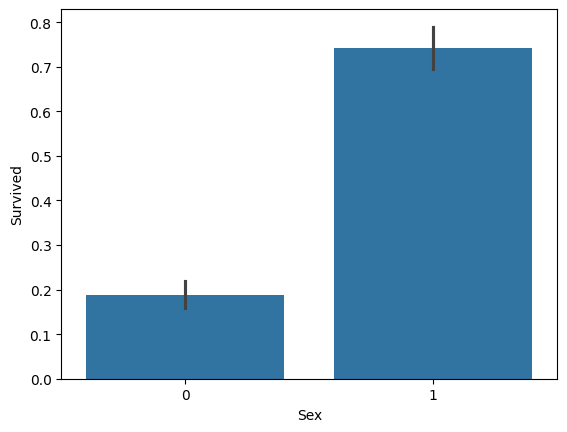

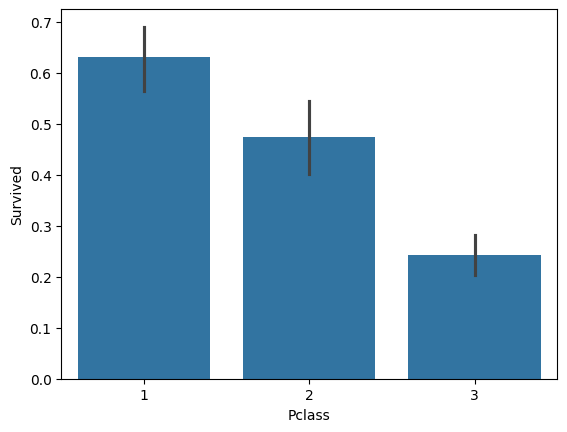

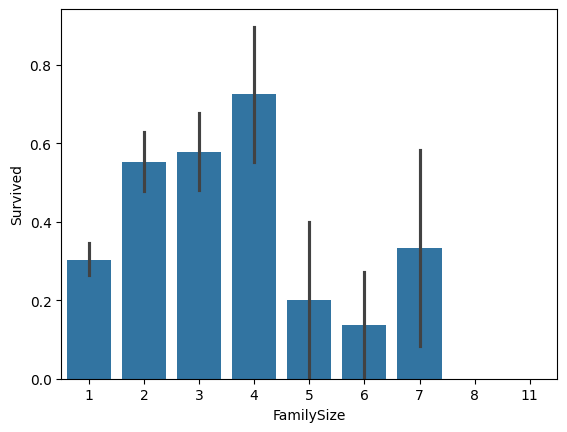

In [26]:
# 5. Data Visualization

import seaborn as sns
import matplotlib.pyplot as plt

# Plot survival rate by sex
sns.barplot(x='Sex', y='Survived', data=titanic_data)
plt.show()

# Plot survival rate by Pclass
sns.barplot(x='Pclass', y='Survived', data=titanic_data)
plt.show()

# Plot survival rate by FamilySize
sns.barplot(x='FamilySize', y='Survived', data=titanic_data)
plt.show()


In [27]:
# 6. Building a Predictive Model

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Define features and target variable
X = titanic_data.drop(columns=['Survived'])
y = titanic_data['Survived']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.8268156424581006
Confusion Matrix:
 [[92 13]
 [18 56]]
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.88      0.86       105
           1       0.81      0.76      0.78        74

    accuracy                           0.83       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



Sex           0.266067
Fare          0.259567
Age           0.244288
Pclass        0.083510
FamilySize    0.051313
SibSp         0.033287
Parch         0.025125
Embarked_S    0.017133
Embarked_C    0.012893
Embarked_Q    0.006817
dtype: float64


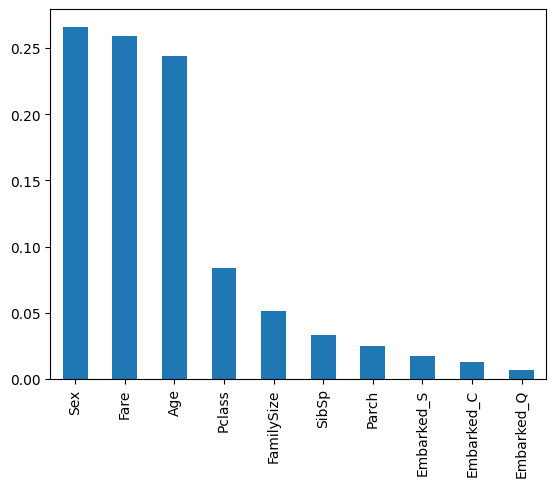

In [28]:
# 7. Model Interpretation

# Feature importance
feature_importances = pd.Series(model.feature_importances_, index=X.columns)
feature_importances.sort_values(ascending=False, inplace=True)
print(feature_importances)

# Plot feature importance
feature_importances.plot(kind='bar')
plt.show()


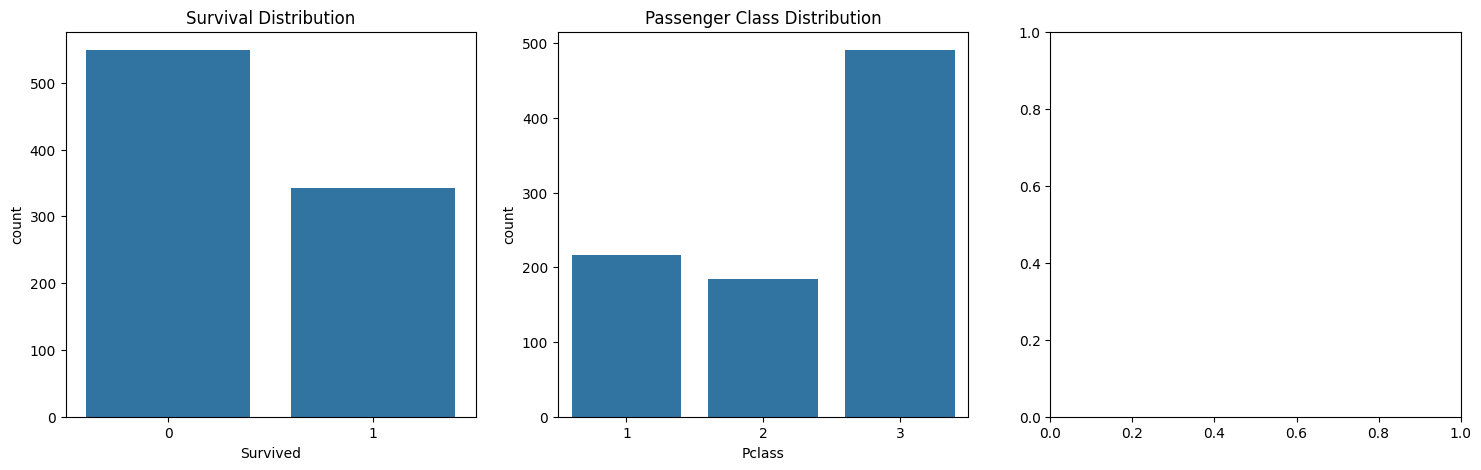

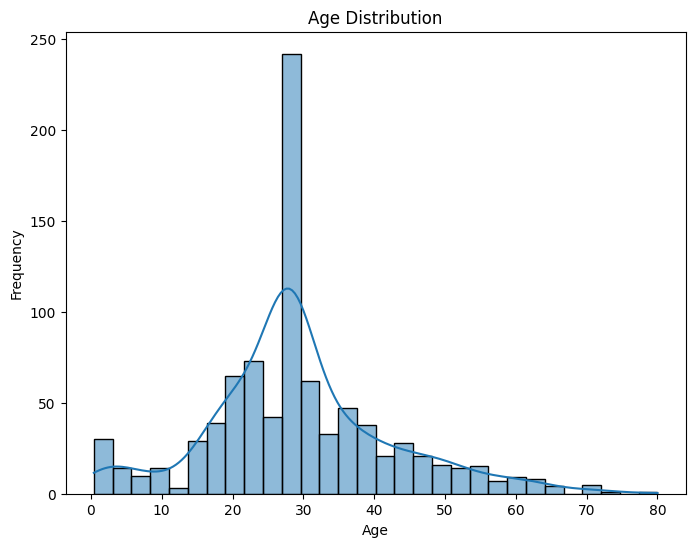

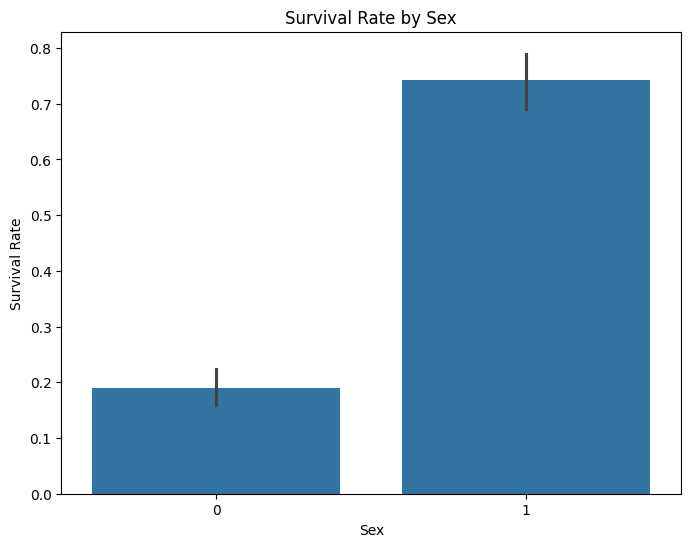

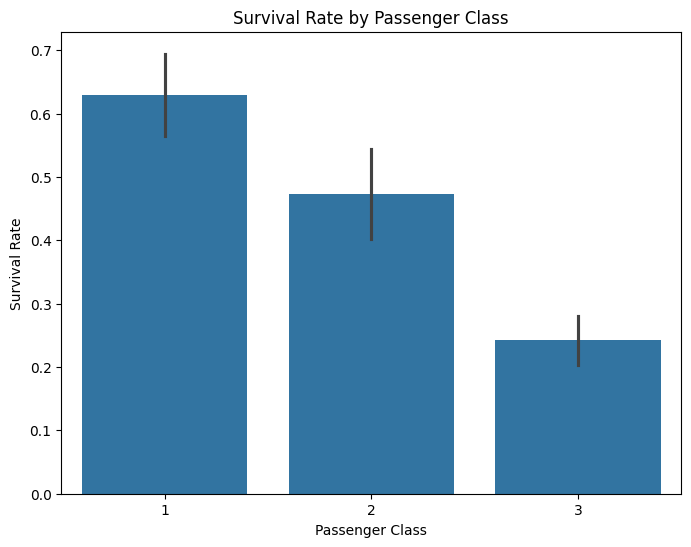

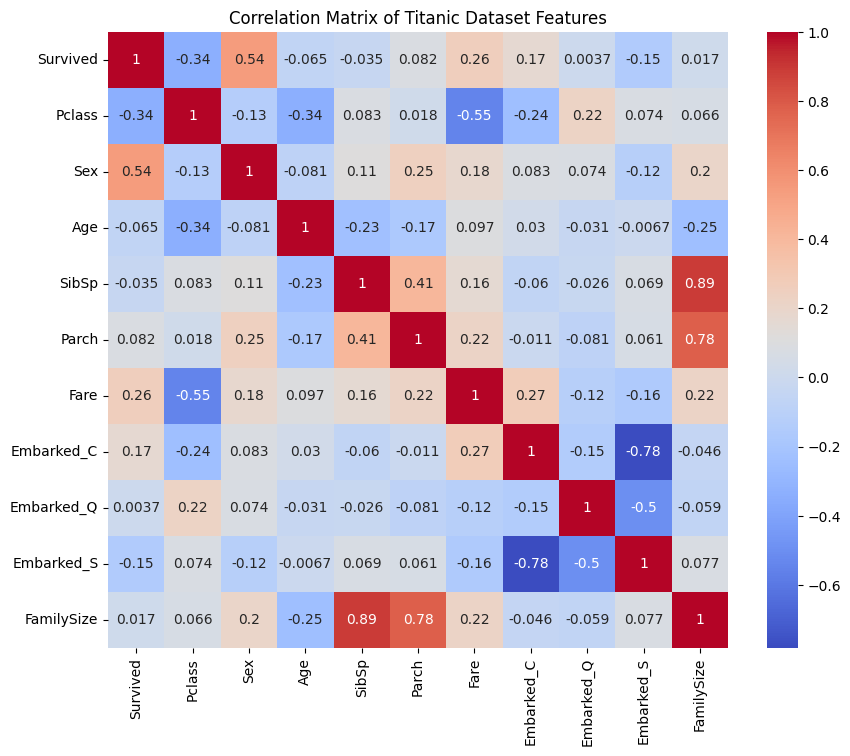

In [34]:
# Distribution of key categorical features
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# Survival distribution
sns.countplot(x='Survived', data=titanic_data, ax=ax[0])
ax[0].set_title('Survival Distribution')

# Pclass distribution
sns.countplot(x='Pclass', data=titanic_data, ax=ax[1])
ax[1].set_title('Passenger Class Distribution')

# # Embarked distribution
# sns.countplot(x='Embarked', data=titanic_data, ax=ax[2])
# ax[2].set_title('Port of Embarkation Distribution')

# plt.show()

# Distribution of Age
plt.figure(figsize=(8, 6))
sns.histplot(titanic_data['Age'].dropna(), kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

# Survival rate by sex
plt.figure(figsize=(8, 6))
sns.barplot(x='Sex', y='Survived', data=titanic_data)
plt.title('Survival Rate by Sex')
plt.xlabel('Sex')
plt.ylabel('Survival Rate')
plt.show()

# Survival rate by class
plt.figure(figsize=(8, 6))
sns.barplot(x='Pclass', y='Survived', data=titanic_data)
plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.show()

# Correlation matrix
corr_matrix_titanic = titanic_data.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix_titanic, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Titanic Dataset Features')
plt.show()


In [36]:
# Checking for missing values
missing_values = titanic_data.isnull().sum()

# Basic statistics for numerical columns
basic_stats = titanic_data.describe()

missing_values, basic_stats


(Survived      0
 Pclass        0
 Sex           0
 Age           0
 SibSp         0
 Parch         0
 Fare          0
 Embarked_C    0
 Embarked_Q    0
 Embarked_S    0
 FamilySize    0
 dtype: int64,
          Survived      Pclass         Sex         Age       SibSp       Parch  \
 count  891.000000  891.000000  891.000000  891.000000  891.000000  891.000000   
 mean     0.383838    2.308642    0.352413   29.361582    0.523008    0.381594   
 std      0.486592    0.836071    0.477990   13.019697    1.102743    0.806057   
 min      0.000000    1.000000    0.000000    0.420000    0.000000    0.000000   
 25%      0.000000    2.000000    0.000000   22.000000    0.000000    0.000000   
 50%      0.000000    3.000000    0.000000   28.000000    0.000000    0.000000   
 75%      1.000000    3.000000    1.000000   35.000000    1.000000    0.000000   
 max      1.000000    3.000000    1.000000   80.000000    8.000000    6.000000   
 
              Fare  FamilySize  
 count  891.000000  891.0

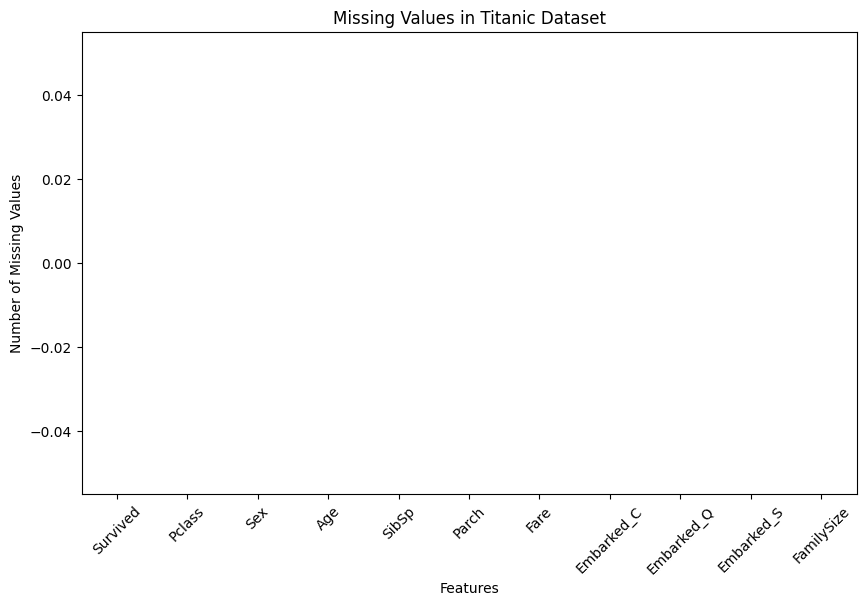

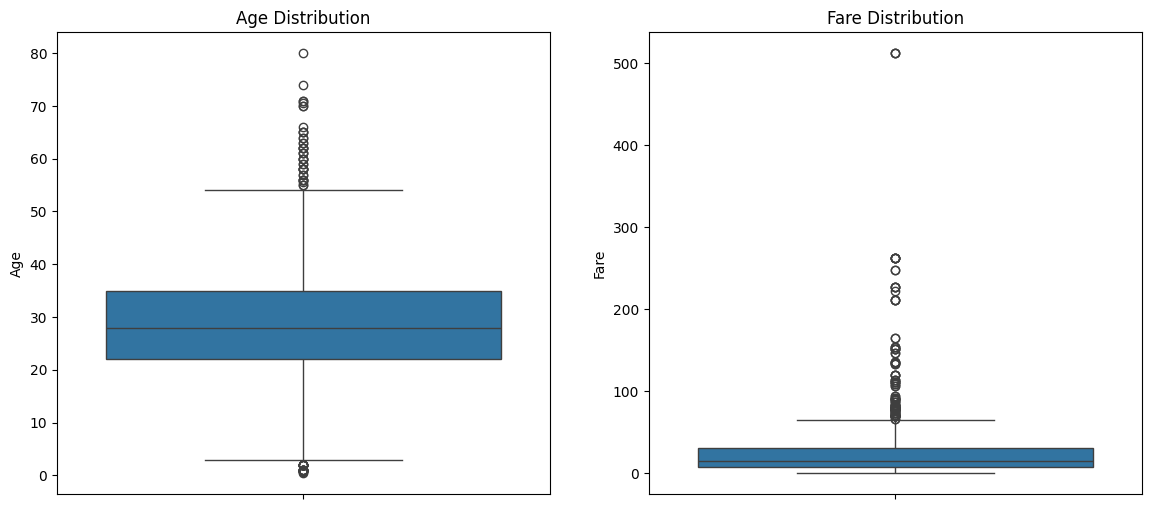

In [37]:
# Plotting missing values
plt.figure(figsize=(10, 6))
sns.barplot(x=missing_values.index, y=missing_values.values)
plt.title('Missing Values in Titanic Dataset')
plt.xlabel('Features')
plt.ylabel('Number of Missing Values')
plt.xticks(rotation=45)
plt.show()

# Basic statistics visualization for numerical features
# Boxplots for Age and Fare to show the distribution and potential outliers
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(y=titanic_data['Age'], ax=ax[0])
ax[0].set_title('Age Distribution')

sns.boxplot(y=titanic_data['Fare'], ax=ax[1])
ax[1].set_title('Fare Distribution')

plt.show()


In [38]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [41]:
titanic_data.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked_C', 'Embarked_Q', 'Embarked_S', 'FamilySize'],
      dtype='object')

In [45]:
# Preparing the data
X = titanic_data.drop(['Survived'], axis=1)
y = titanic_data['Survived']

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Defining numerical and categorical features
num_features = ['Age', 'SibSp', 'Parch', 'Fare']
cat_features = ['Pclass', 'Sex']

In [46]:
# Creating the preprocessing pipelines
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder())
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features)
])

# Defining the models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100),
    'SVM': SVC()
}

results = []

In [47]:
# Training and evaluating the models
for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    cv_score = cross_val_score(pipeline, X, y, cv=5).mean()

    results.append({'Model': name, 'Test Accuracy': accuracy, 'CV Score': cv_score})

In [48]:
# Converting results to DataFrame for better visualization
results_df = pd.DataFrame(results)

results_df

,Model,Test Accuracy,CV Score
0,Logistic Regression,0.804469,0.787879
1,Random Forest,0.798883,0.813734
2,SVM,0.810056,0.828278
